# TP – CNN "from scratch" vs Transfert Learning (Cats vs Dogs)
**Objectif :** Comparer un CNN entraîné from scratch et un modèle en transfert learning.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

#Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')

Device utilisé : cuda


## 1. Chargement des données


### 1.1 Partie exercice — chargement simple

In [2]:
data_dir = '/kaggle/input/datasets/abdoulwahabsoumare/catdogbysouna/Cat_Dog_data/train'

# Transformations
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

dataset   = datasets.ImageFolder(data_dir, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

print(f'Classes : {dataset.classes}')
print(f'Nombre d\'images : {len(dataset)}')

Classes : ['cat', 'dog']
Nombre d'images : 22500


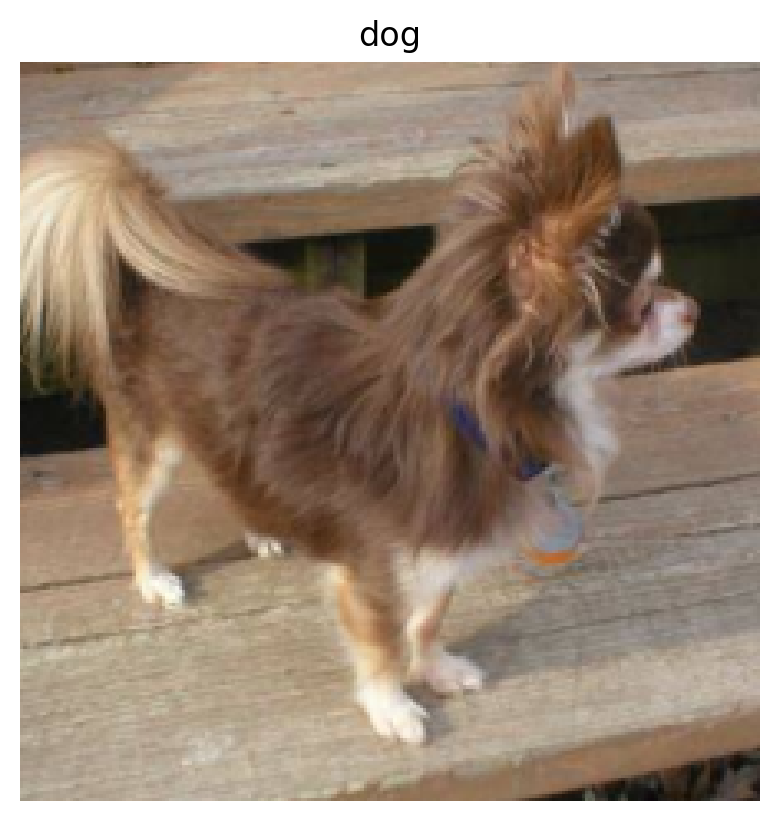

In [3]:
def imshow(image, ax=None, title=None, normalize=True):
    """Imshow pour Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    image = image.numpy().transpose((1, 2, 0))
    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)
    ax.imshow(image)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')
    return ax

# Test
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)
plt.title(dataset.classes[labels[0]])
plt.show()

### 1.2 Transformations des données d'entrainement et de test

In [4]:
data_dir = '/kaggle/input/datasets/abdoulwahabsoumare/catdogbysouna/Cat_Dog_data'

train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data  = datasets.ImageFolder(data_dir + '/test',  transform=test_transforms)

# Split train → 80% train / 20% val
val_size   = int(0.2 * len(train_data))
train_size = len(train_data) - val_size
train_set, val_set = torch.utils.data.random_split(
    train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

trainloader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
valloader   = torch.utils.data.DataLoader(val_set,   batch_size=32, shuffle=False)
testloader  = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

print(f'Train : {train_size} | Val : {val_size} | Test : {len(test_data)}')

Train : 18000 | Val : 4500 | Test : 2500


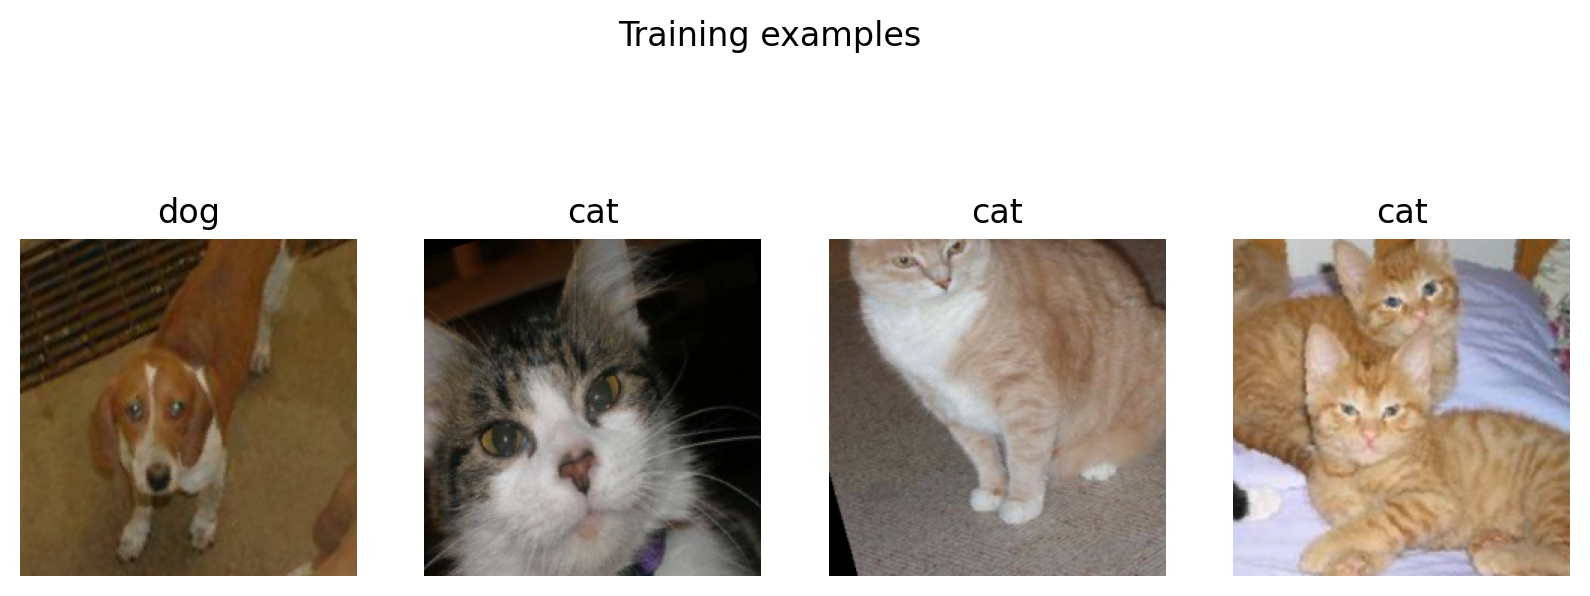

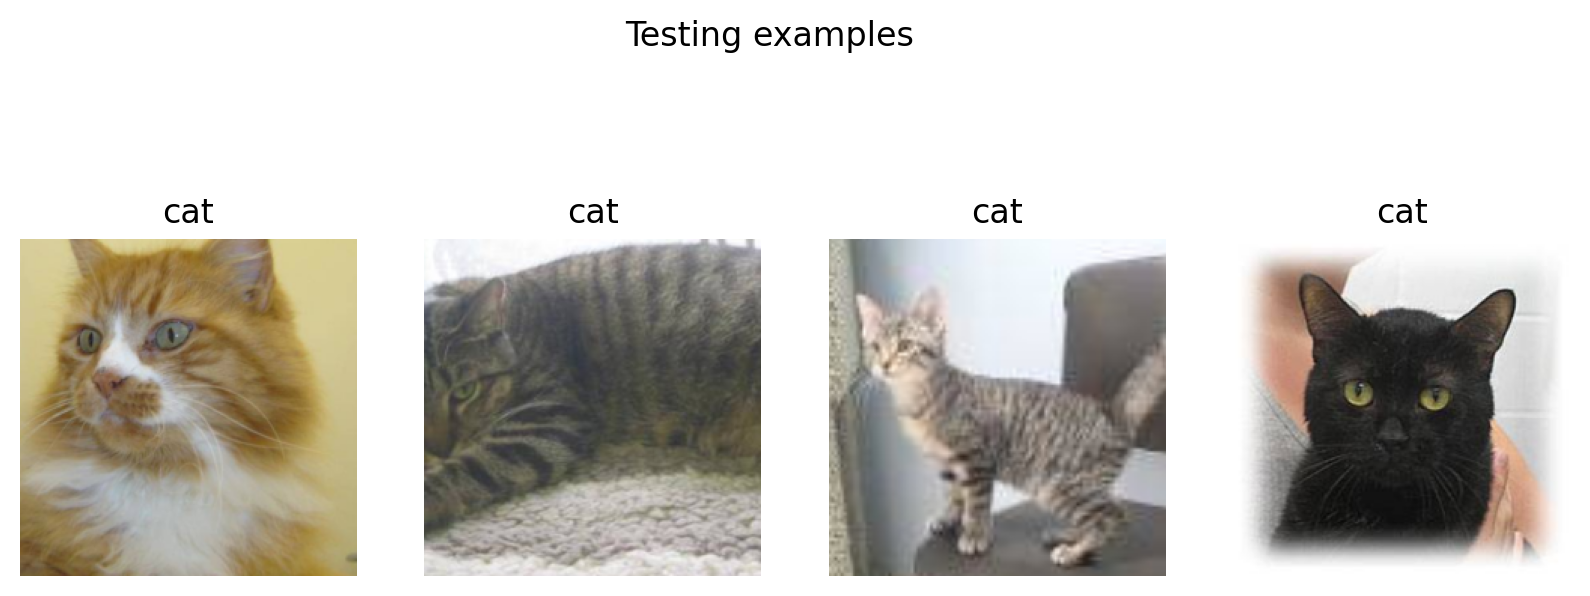

In [5]:
# Visualisation de quelques images d'entraînement et de test
data_iter = iter(trainloader)
images, labels = next(data_iter)

fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=False)
    ax.set_title(train_data.classes[labels[ii]])
plt.suptitle('Training examples')
plt.show()

# Images de test
data_iter_test = iter(testloader)
images, labels = next(data_iter_test)

fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=False)
    ax.set_title(test_data.classes[labels[ii]])
plt.suptitle('Testing examples')
plt.show()

## 2. Fonctions utilitaires communes

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Entraîne le modèle sur une époque. Retourne loss et accuracy."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Évalue le modèle. Retourne loss, accuracy, precision, recall."""
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    n = len(all_labels)
    acc  = np.mean(np.array(all_preds) == np.array(all_labels))
    prec = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    return running_loss / n, acc, prec, rec, all_preds, all_labels


def train_model(model, trainloader, valloader, criterion, optimizer, scheduler=None,
                epochs=20, save_path='best_model.pth'):
    """Boucle d'entraînement complète avec suivi des métriques."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'val_prec': [], 'val_rec': []}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, trainloader, criterion, optimizer)
        v_loss, v_acc, v_prec, v_rec, _, _ = evaluate(model, valloader, criterion)

        if scheduler:
            scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(v_acc)
        history['val_prec'].append(v_prec)
        history['val_rec'].append(v_rec)

        # Sauvegarde du meilleur modèle
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), save_path)

        print(f'Epoch {epoch:02d}/{epochs} | '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
              f'Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} '
              f'Prec: {v_prec:.4f} Rec: {v_rec:.4f}')

    print(f'\nMeilleure Val Acc : {best_val_acc:.4f} — modèle sauvegardé dans {save_path}')
    return history


def plot_history(history, title=''):
    """Trace les courbes loss/accuracy/precision/recall."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, history['train_loss'], label='Train')
    axes[0].plot(epochs, history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='Train')
    axes[1].plot(epochs, history['val_acc'],   label='Val')
    axes[1].set_title('Accuracy'); axes[1].legend()

    axes[2].plot(epochs, history['val_prec'], label='Précision')
    axes[2].plot(epochs, history['val_rec'],  label='Recall')
    axes[2].set_title('Précision & Recall (val)'); axes[2].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_confusion_matrix(model, loader, classes, title=''):
    """Affiche la matrice de confusion."""
    criterion = nn.CrossEntropyLoss()
    _, _, _, _, preds, labels = evaluate(model, loader, criterion)
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.show()

In [7]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transforms = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data  = datasets.ImageFolder(data_dir + '/test',  transform=test_transforms)

val_size   = int(0.2 * len(train_data))
train_size = len(train_data) - val_size
train_set, val_set = torch.utils.data.random_split(
    train_data, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

trainloader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
valloader   = torch.utils.data.DataLoader(val_set,   batch_size=32, shuffle=False)
testloader  = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

print(f'Train : {train_size} | Val : {val_size} | Test : {len(test_data)}')

Train : 18000 | Val : 4500 | Test : 2500


In [8]:
criterion = nn.CrossEntropyLoss()

## 3. Expérience A — CNN From Scratch

Architecture : 3 blocs **Conv → BN → ReLU → MaxPool**, suivis de couches fully-connected avec **Dropout**.

**Justifications :**
- **Batch Normalization** après chaque convolution : stabilise l'entraînement, réduit la sensibilité au learning rate.
- **Dropout(0.5)** dans le classifieur : régularisation pour éviter le sur-apprentissage.

In [9]:
class CatDogCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        # Bloc 1 : 3 → 32 canaux
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)          # 224 → 112
        )
        # Bloc 2 : 32 → 64 canaux
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)          # 112 → 56
        )
        # Bloc 3 : 64 → 128 canaux
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)          # 56 → 28
        )
        # Classifieur
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return self.classifier(x)


scratch_model = CatDogCNN(dropout_p=0.5).to(device)
print(scratch_model)
total_params = sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)
print(f'\nParamètres entraînables : {total_params:,}')

CatDogCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1

### 3.1 Optimiseur SGD — Expérience A

In [10]:
scratch_model_sgd = CatDogCNN(dropout_p=0.5).to(device)
optimizer_sgd = optim.SGD(scratch_model_sgd.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
scheduler_sgd = lr_scheduler.StepLR(optimizer_sgd, step_size=7, gamma=0.1)

print('=== Entraînement From Scratch — SGD ===')
history_scratch_sgd = train_model(
    scratch_model_sgd, trainloader, valloader, criterion, optimizer_sgd,
    scheduler=scheduler_sgd, epochs=10, save_path='/kaggle/working/best_scratch_sgd.pth'
)

=== Entraînement From Scratch — SGD ===
Epoch 01/10 | Train Loss: 0.6676 Acc: 0.5980 | Val Loss: 0.6285 Acc: 0.6336 Prec: 0.6194 Rec: 0.6961
Epoch 02/10 | Train Loss: 0.6376 Acc: 0.6292 | Val Loss: 0.6135 Acc: 0.6524 Prec: 0.6548 Rec: 0.6473
Epoch 03/10 | Train Loss: 0.6266 Acc: 0.6461 | Val Loss: 0.6035 Acc: 0.6622 Prec: 0.6634 Rec: 0.6610
Epoch 04/10 | Train Loss: 0.6185 Acc: 0.6522 | Val Loss: 0.6082 Acc: 0.6518 Prec: 0.6283 Rec: 0.7462
Epoch 05/10 | Train Loss: 0.6193 Acc: 0.6572 | Val Loss: 0.6166 Acc: 0.6471 Prec: 0.7573 Rec: 0.4348
Epoch 06/10 | Train Loss: 0.6092 Acc: 0.6667 | Val Loss: 0.6005 Acc: 0.6802 Prec: 0.7365 Rec: 0.5630
Epoch 07/10 | Train Loss: 0.6053 Acc: 0.6717 | Val Loss: 0.5940 Acc: 0.6831 Prec: 0.7382 Rec: 0.5692
Epoch 08/10 | Train Loss: 0.5755 Acc: 0.6988 | Val Loss: 0.5616 Acc: 0.7007 Prec: 0.7222 Rec: 0.6539
Epoch 09/10 | Train Loss: 0.5709 Acc: 0.7014 | Val Loss: 0.5536 Acc: 0.7100 Prec: 0.7617 Rec: 0.6127
Epoch 10/10 | Train Loss: 0.5644 Acc: 0.7064 | Val 

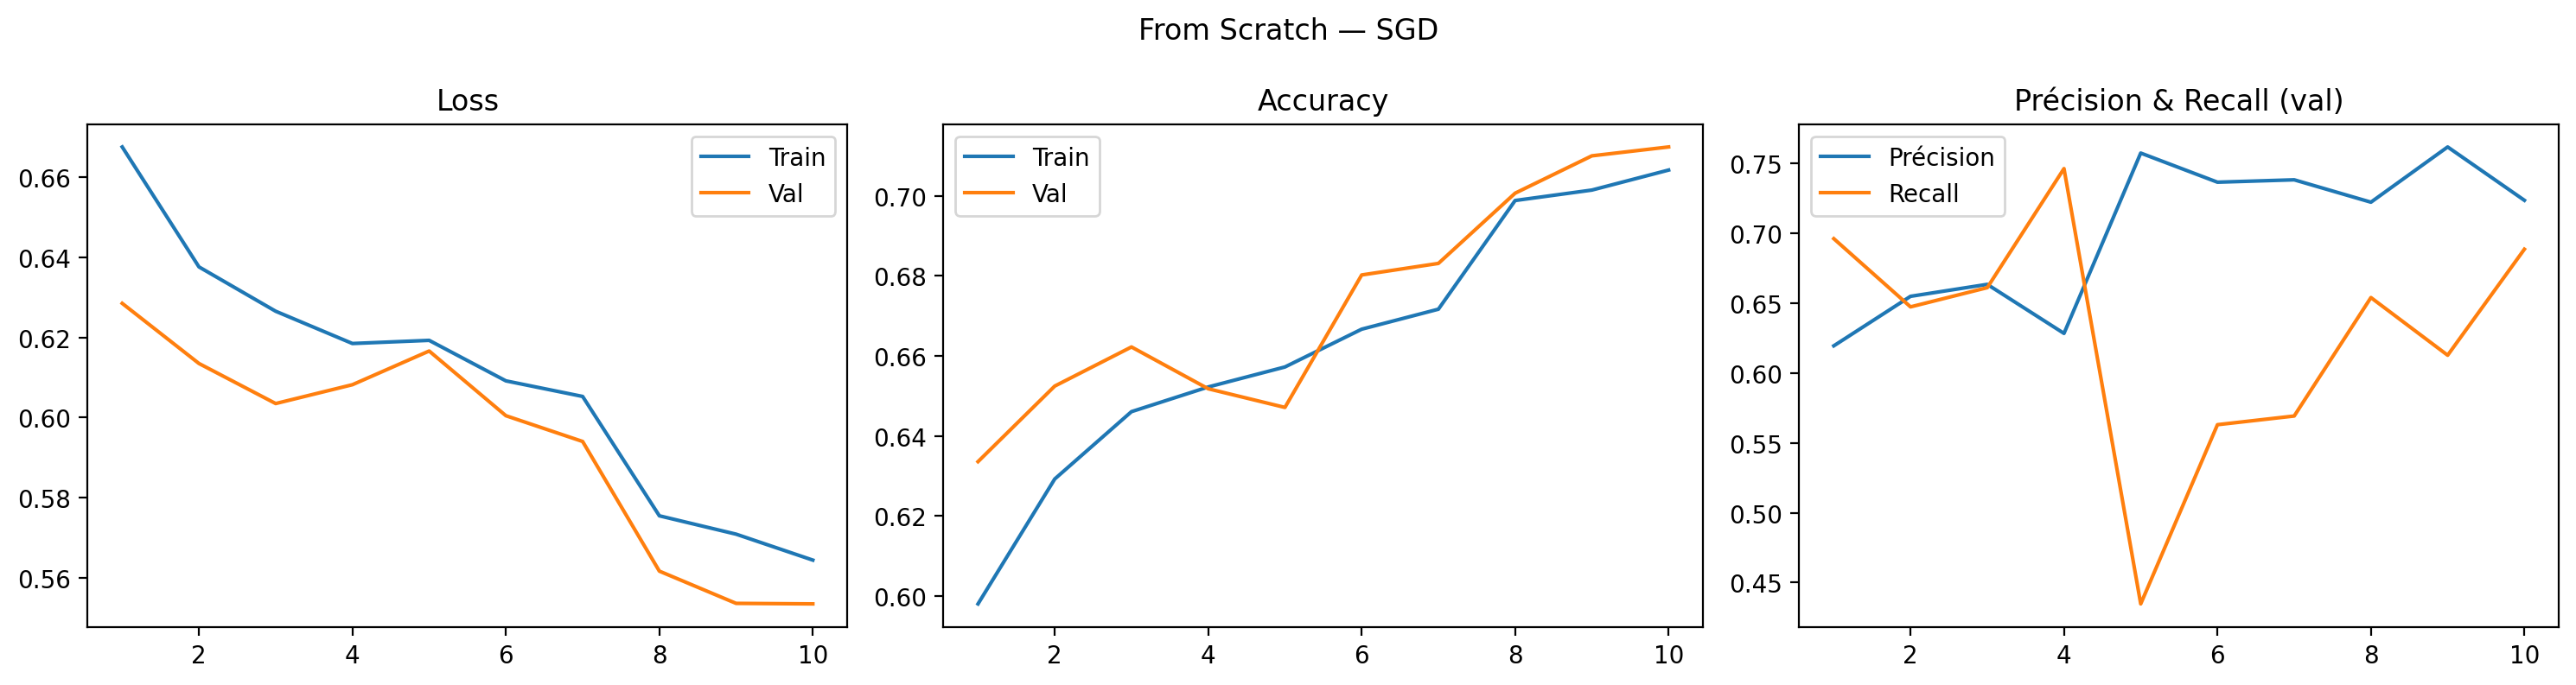

In [11]:
plot_history(history_scratch_sgd, title='From Scratch — SGD')

### 3.2 Optimiseur Adam — Expérience A

In [12]:
scratch_model_adam = CatDogCNN(dropout_p=0.5).to(device)
optimizer_adam = optim.Adam(scratch_model_adam.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_adam = lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=20)

print('=== Entraînement From Scratch — Adam ===')
history_scratch_adam = train_model(
    scratch_model_adam, trainloader, valloader, criterion, optimizer_adam,
    scheduler=scheduler_adam, epochs=10, save_path='/kaggle/working/best_scratch_adam.pth'
)

=== Entraînement From Scratch — Adam ===
Epoch 01/10 | Train Loss: 0.7803 Acc: 0.5932 | Val Loss: 0.6319 Acc: 0.6336 Prec: 0.6918 Rec: 0.4840
Epoch 02/10 | Train Loss: 0.6313 Acc: 0.6416 | Val Loss: 0.6157 Acc: 0.6476 Prec: 0.6147 Rec: 0.7941
Epoch 03/10 | Train Loss: 0.6077 Acc: 0.6648 | Val Loss: 0.6000 Acc: 0.6776 Prec: 0.7139 Rec: 0.5945
Epoch 04/10 | Train Loss: 0.5965 Acc: 0.6791 | Val Loss: 0.5827 Acc: 0.6909 Prec: 0.6883 Rec: 0.6996
Epoch 05/10 | Train Loss: 0.5800 Acc: 0.6937 | Val Loss: 0.5630 Acc: 0.7038 Prec: 0.7003 Rec: 0.7143
Epoch 06/10 | Train Loss: 0.5737 Acc: 0.6971 | Val Loss: 0.5554 Acc: 0.7029 Prec: 0.7422 Rec: 0.6233
Epoch 07/10 | Train Loss: 0.5646 Acc: 0.7058 | Val Loss: 0.5410 Acc: 0.7211 Prec: 0.7377 Rec: 0.6877
Epoch 08/10 | Train Loss: 0.5546 Acc: 0.7143 | Val Loss: 0.5551 Acc: 0.7004 Prec: 0.6846 Rec: 0.7453
Epoch 09/10 | Train Loss: 0.5476 Acc: 0.7208 | Val Loss: 0.5443 Acc: 0.7096 Prec: 0.7564 Rec: 0.6198
Epoch 10/10 | Train Loss: 0.5401 Acc: 0.7293 | Val

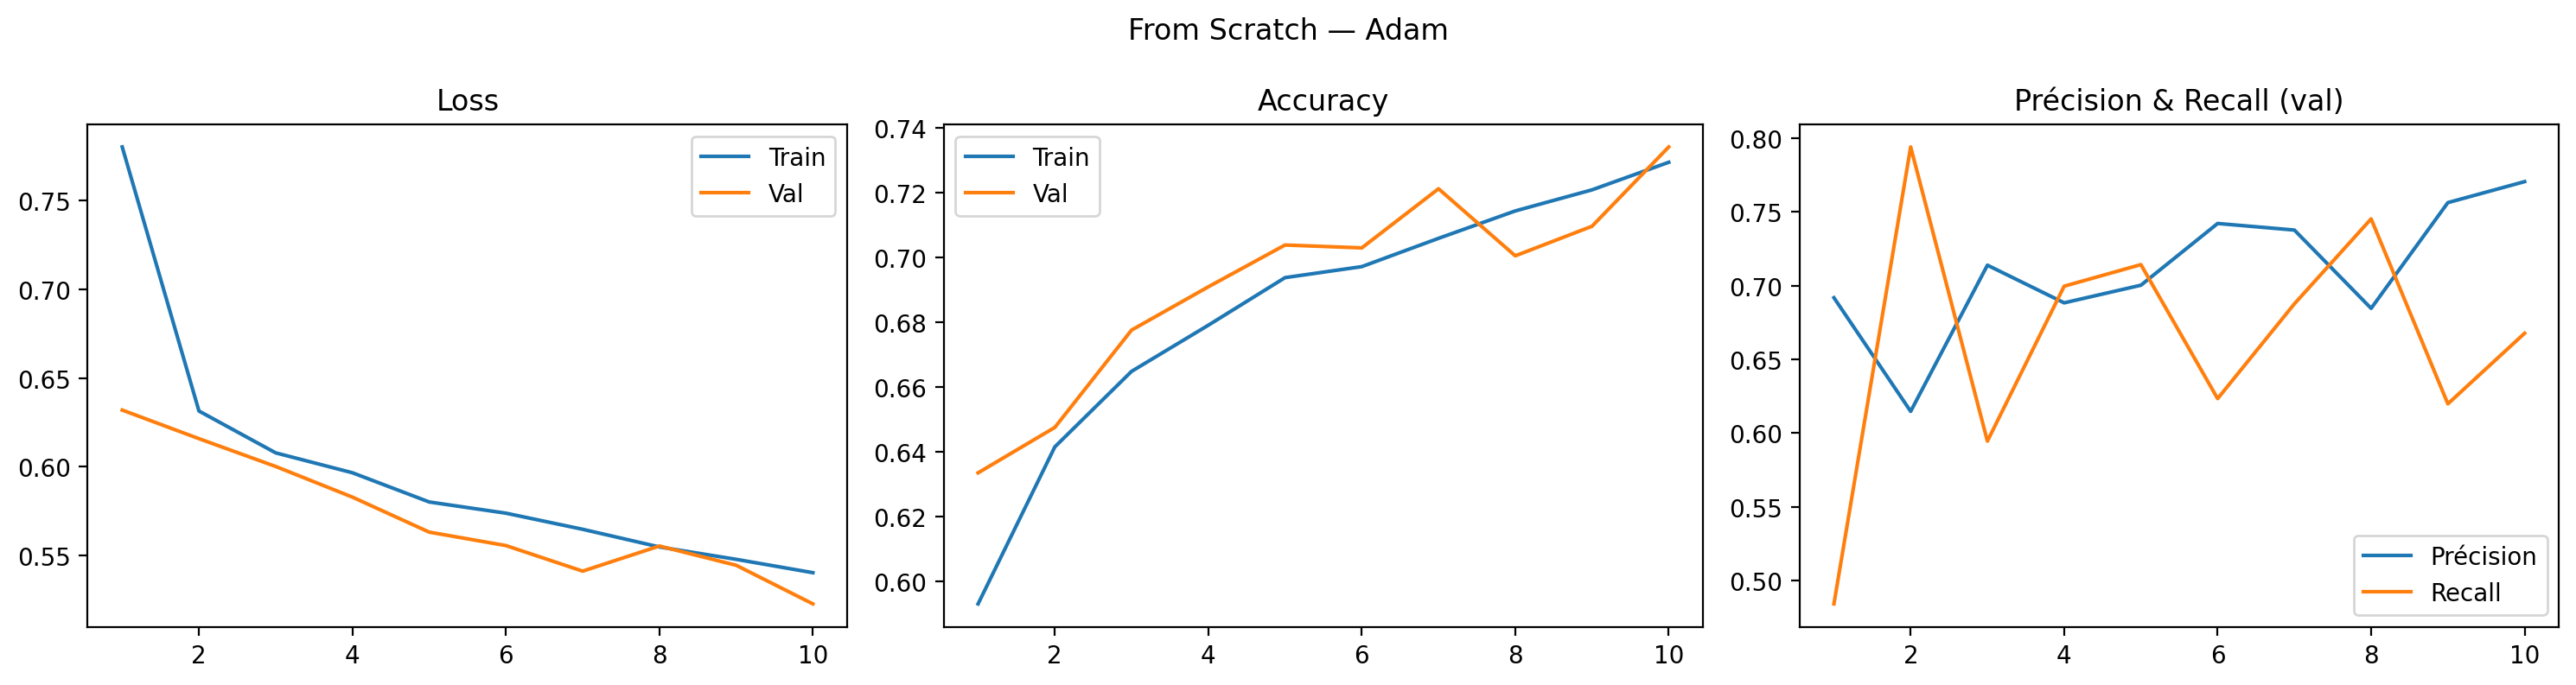

In [13]:
plot_history(history_scratch_adam, title='From Scratch — Adam')

### 3.3 Évaluation finale — From Scratch

Test — Accuracy: 0.7836 | Précision: 0.8022 | Recall: 0.7528


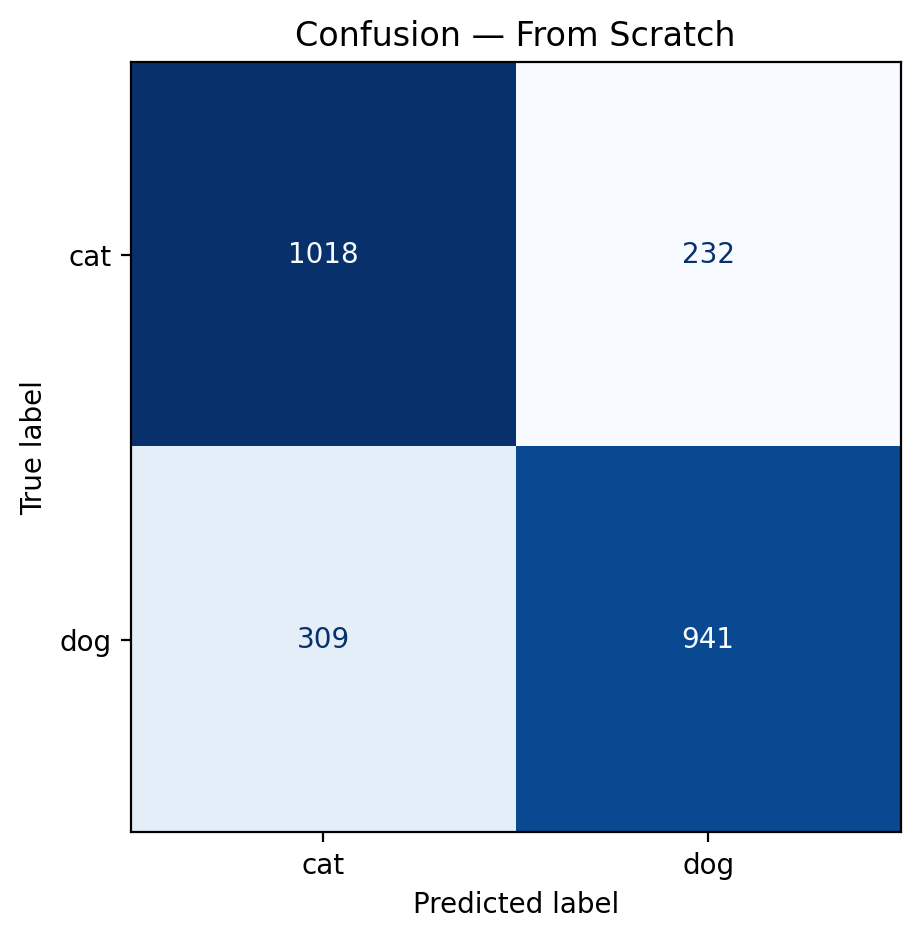

In [14]:
# On charge le meilleur modèle Adam
best_scratch = CatDogCNN(dropout_p=0.5).to(device)
best_scratch.load_state_dict(torch.load('best_scratch_adam.pth', map_location=device))

_, test_acc, test_prec, test_rec, _, _ = evaluate(best_scratch, testloader, criterion)
print(f'Test — Accuracy: {test_acc:.4f} | Précision: {test_prec:.4f} | Recall: {test_rec:.4f}')

show_confusion_matrix(best_scratch, testloader, train_data.classes, title='Confusion — From Scratch')

## 4. Expérience B — Transfert Learning (ResNet-18)

On utilise **ResNet-18** pré-entraîné sur ImageNet.
Stratégie : **fine-tuning complet** (toutes les couches dégelées) avec un learning rate plus faible pour les couches de base.

In [ ]:
def build_resnet18(freeze_backbone=False):
    
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Remplace la couche fully-connected finale
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 2)
    )
    return model.to(device)


tl_model = build_resnet18(freeze_backbone=False)
total_params = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f'Paramètres entraînables (fine-tuning complet) : {total_params:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]

Paramètres entraînables (fine-tuning complet) : 11,177,538


### 4.1 Optimiseur SGD — Transfert Learning

In [16]:
tl_model_sgd = build_resnet18(freeze_backbone=False)

# Learning rate différencié : backbone lr faible, tête lr normal
optimizer_tl_sgd = optim.SGD([
    {'params': [p for n, p in tl_model_sgd.named_parameters() if 'fc' not in n], 'lr': 1e-3},
    {'params': tl_model_sgd.fc.parameters(), 'lr': 1e-2}
], momentum=0.9, weight_decay=1e-4)

scheduler_tl_sgd = lr_scheduler.StepLR(optimizer_tl_sgd, step_size=7, gamma=0.1)

print('=== Transfert Learning (ResNet-18) — SGD ===')
history_tl_sgd = train_model(
    tl_model_sgd, trainloader, valloader, criterion, optimizer_tl_sgd,
    scheduler=scheduler_tl_sgd, epochs=10, save_path='/kaggle/working/best_tl_sgd.pth'
)

=== Transfert Learning (ResNet-18) — SGD ===
Epoch 01/10 | Train Loss: 0.2863 Acc: 0.8972 | Val Loss: 0.1275 Acc: 0.9404 Prec: 0.9518 Rec: 0.9281
Epoch 02/10 | Train Loss: 0.1595 Acc: 0.9348 | Val Loss: 0.1180 Acc: 0.9511 Prec: 0.9433 Rec: 0.9601
Epoch 03/10 | Train Loss: 0.1328 Acc: 0.9433 | Val Loss: 0.1017 Acc: 0.9556 Prec: 0.9634 Rec: 0.9472
Epoch 04/10 | Train Loss: 0.1222 Acc: 0.9489 | Val Loss: 0.0969 Acc: 0.9622 Prec: 0.9619 Rec: 0.9627
Epoch 05/10 | Train Loss: 0.1111 Acc: 0.9536 | Val Loss: 0.0938 Acc: 0.9671 Prec: 0.9684 Rec: 0.9658
Epoch 06/10 | Train Loss: 0.1045 Acc: 0.9553 | Val Loss: 0.0838 Acc: 0.9627 Prec: 0.9750 Rec: 0.9499
Epoch 07/10 | Train Loss: 0.0938 Acc: 0.9604 | Val Loss: 0.0887 Acc: 0.9658 Prec: 0.9692 Rec: 0.9623
Epoch 08/10 | Train Loss: 0.0918 Acc: 0.9602 | Val Loss: 0.0843 Acc: 0.9684 Prec: 0.9668 Rec: 0.9703
Epoch 09/10 | Train Loss: 0.0917 Acc: 0.9600 | Val Loss: 0.0820 Acc: 0.9647 Prec: 0.9755 Rec: 0.9534
Epoch 10/10 | Train Loss: 0.0848 Acc: 0.9647 |

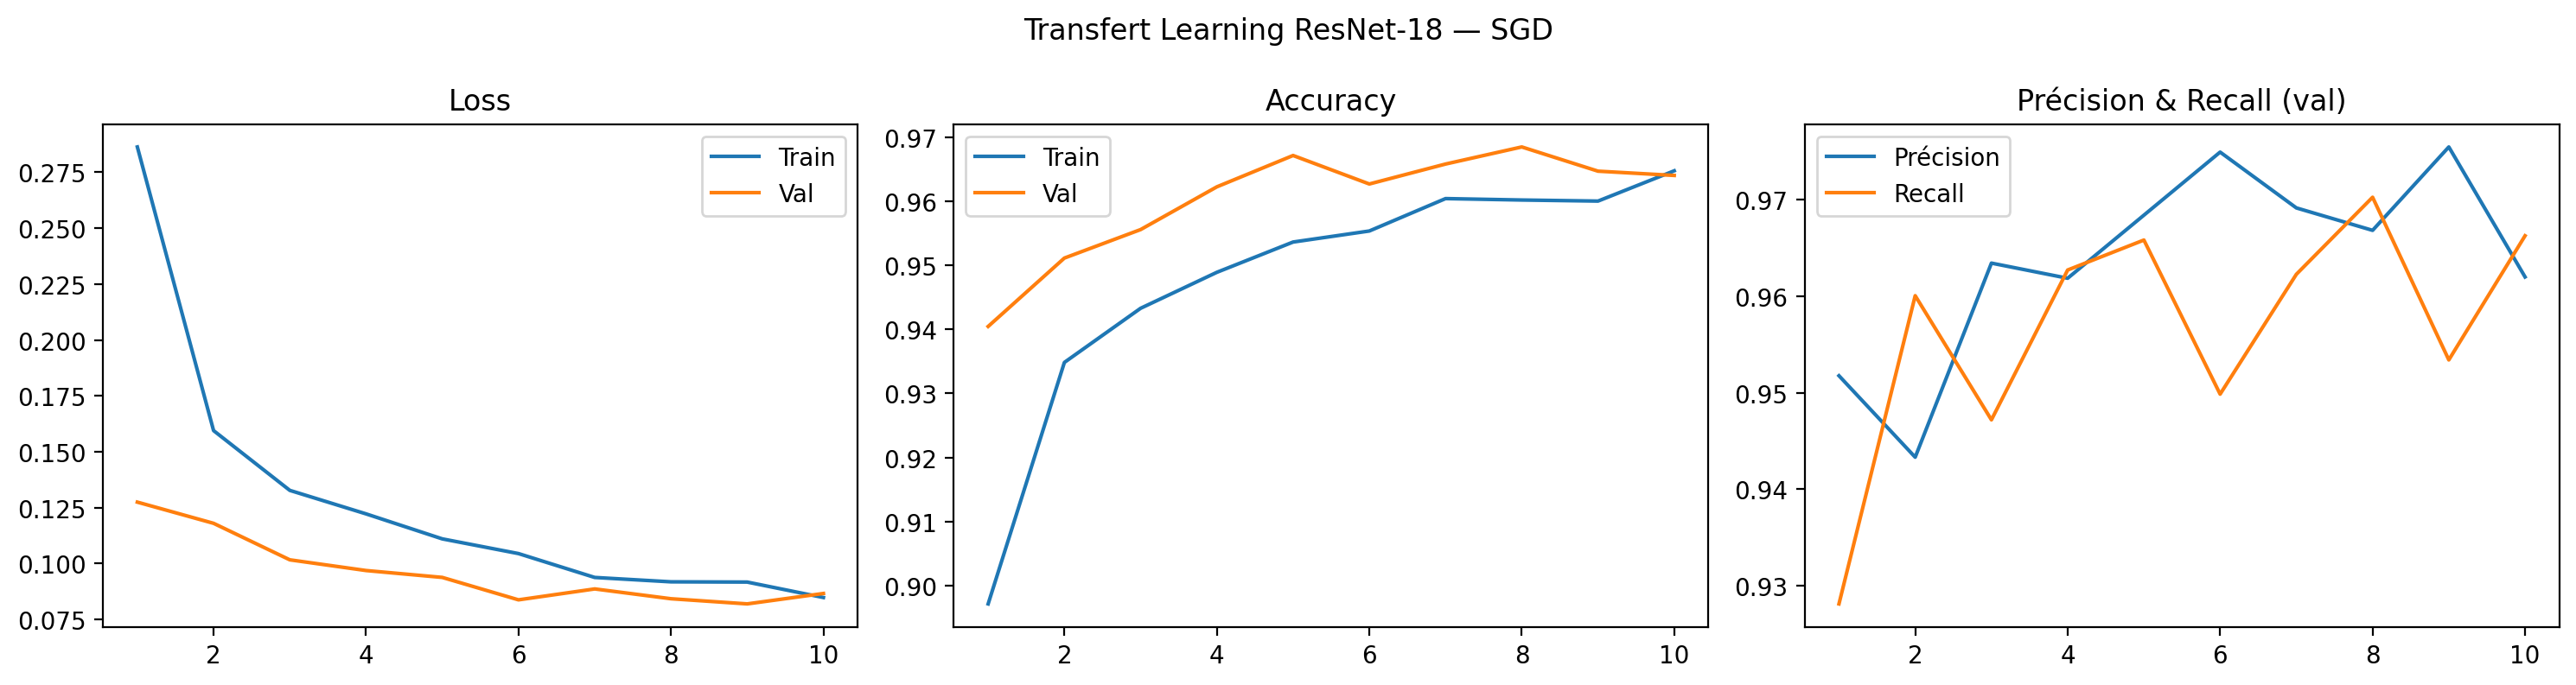

In [17]:
plot_history(history_tl_sgd, title='Transfert Learning ResNet-18 — SGD')

### 4.2 Optimiseur Adam — Transfert Learning

In [18]:
tl_model_adam = build_resnet18(freeze_backbone=False)

optimizer_tl_adam = optim.Adam([
    {'params': [p for n, p in tl_model_adam.named_parameters() if 'fc' not in n], 'lr': 1e-4},
    {'params': tl_model_adam.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler_tl_adam = lr_scheduler.CosineAnnealingLR(optimizer_tl_adam, T_max=15)

print('=== Transfert Learning (ResNet-18) — Adam ===')
history_tl_adam = train_model(
    tl_model_adam, trainloader, valloader, criterion, optimizer_tl_adam,
    scheduler=scheduler_tl_adam, epochs=10, save_path= '/kaggle/working/best_tl_adam.pth'
)

=== Transfert Learning (ResNet-18) — Adam ===
Epoch 01/10 | Train Loss: 0.1705 Acc: 0.9246 | Val Loss: 0.1260 Acc: 0.9469 Prec: 0.9330 Rec: 0.9632
Epoch 02/10 | Train Loss: 0.1375 Acc: 0.9426 | Val Loss: 0.1040 Acc: 0.9542 Prec: 0.9551 Rec: 0.9534
Epoch 03/10 | Train Loss: 0.1272 Acc: 0.9468 | Val Loss: 0.1193 Acc: 0.9509 Prec: 0.9556 Rec: 0.9459
Epoch 04/10 | Train Loss: 0.1157 Acc: 0.9516 | Val Loss: 0.1210 Acc: 0.9487 Prec: 0.9698 Rec: 0.9264
Epoch 05/10 | Train Loss: 0.1128 Acc: 0.9518 | Val Loss: 0.1068 Acc: 0.9536 Prec: 0.9637 Rec: 0.9428
Epoch 06/10 | Train Loss: 0.1005 Acc: 0.9566 | Val Loss: 0.0968 Acc: 0.9616 Prec: 0.9685 Rec: 0.9543
Epoch 07/10 | Train Loss: 0.0906 Acc: 0.9622 | Val Loss: 0.1080 Acc: 0.9549 Prec: 0.9536 Rec: 0.9565
Epoch 08/10 | Train Loss: 0.0875 Acc: 0.9636 | Val Loss: 0.0909 Acc: 0.9642 Prec: 0.9616 Rec: 0.9672
Epoch 09/10 | Train Loss: 0.0861 Acc: 0.9633 | Val Loss: 0.0979 Acc: 0.9636 Prec: 0.9624 Rec: 0.9650
Epoch 10/10 | Train Loss: 0.0769 Acc: 0.9687 

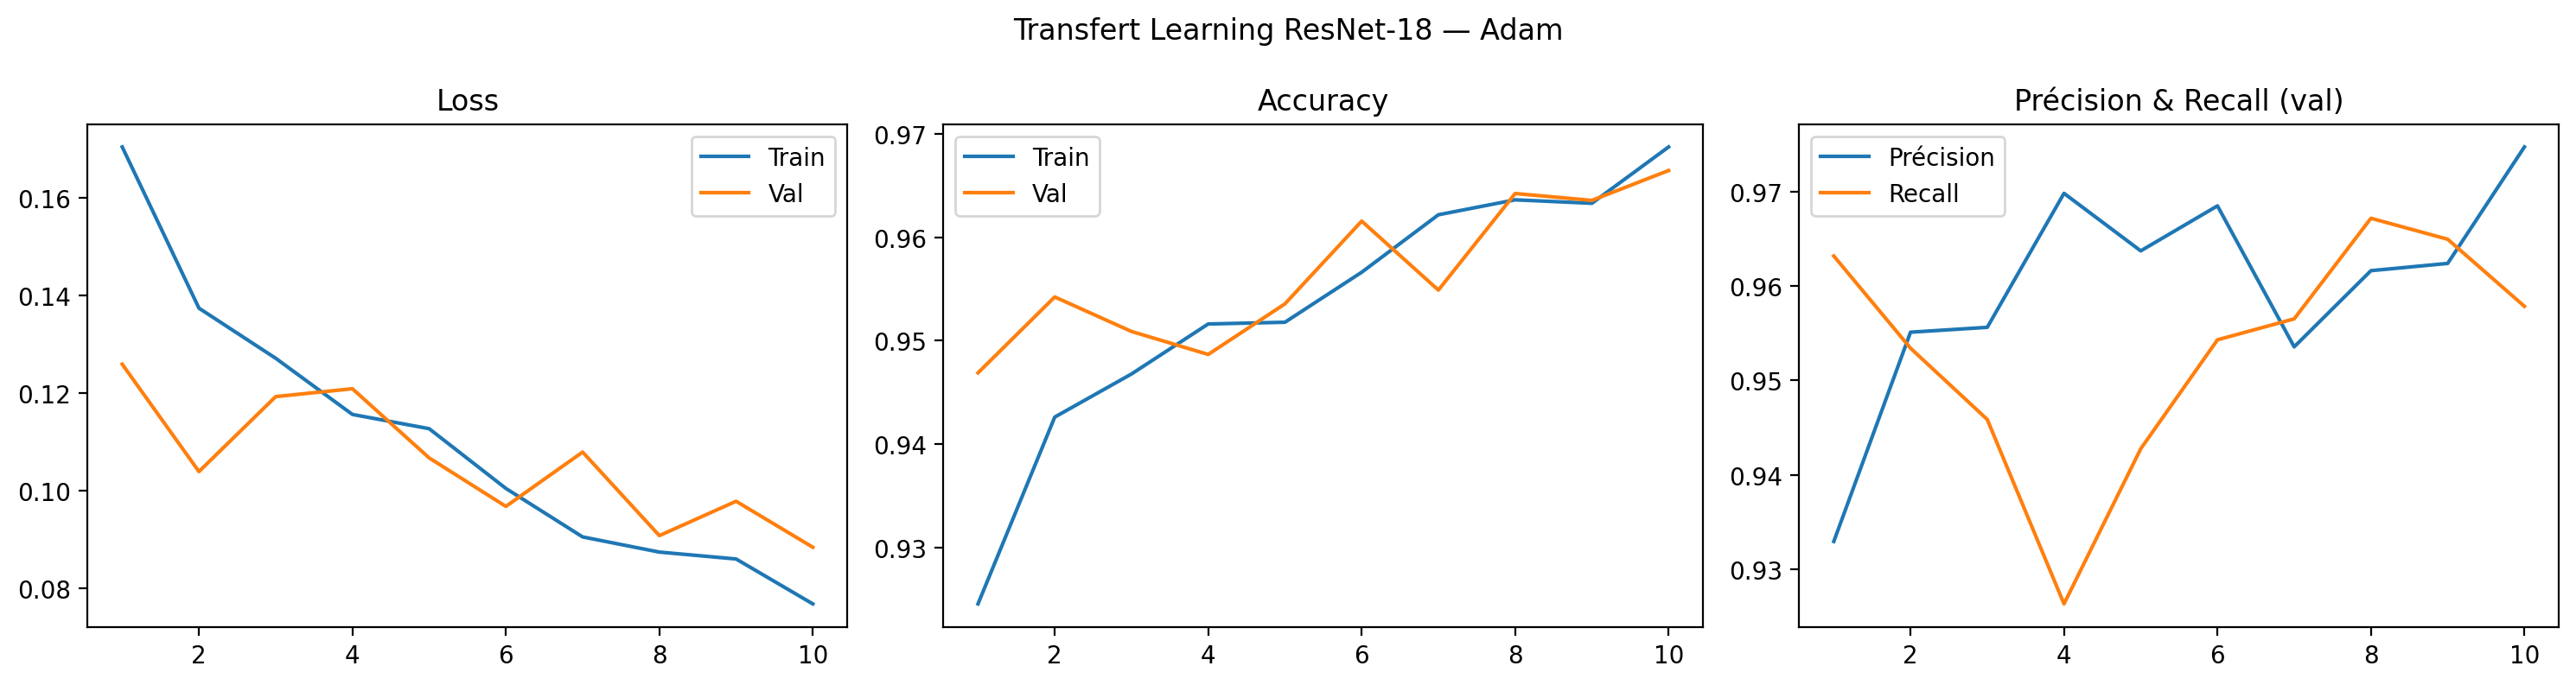

In [19]:
plot_history(history_tl_adam, title='Transfert Learning ResNet-18 — Adam')

### 4.3 Évaluation finale — Transfert Learning (meilleur checkpoint)

Test — Accuracy: 0.9884 | Précision: 0.9865 | Recall: 0.9904


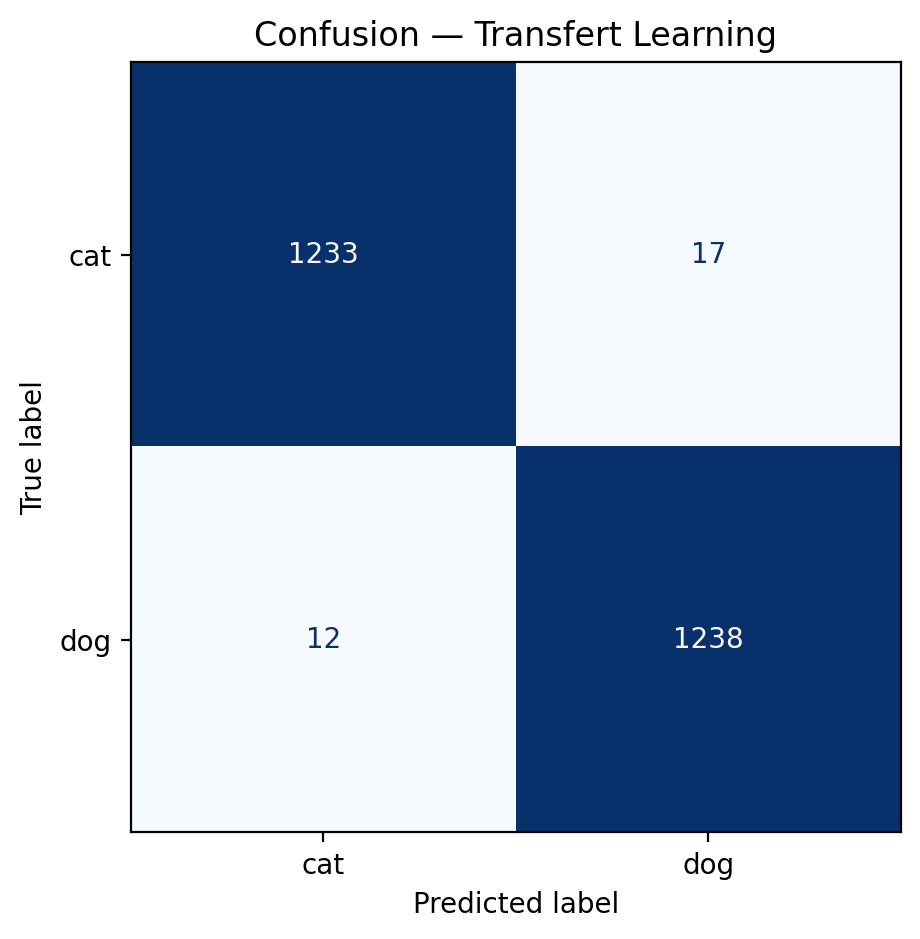

In [20]:
best_tl = build_resnet18()
best_tl.load_state_dict(torch.load('best_tl_adam.pth', map_location=device))

_, test_acc_tl, test_prec_tl, test_rec_tl, _, _ = evaluate(best_tl, testloader, criterion)
print(f'Test — Accuracy: {test_acc_tl:.4f} | Précision: {test_prec_tl:.4f} | Recall: {test_rec_tl:.4f}')

show_confusion_matrix(best_tl, testloader, train_data.classes, title='Confusion — Transfert Learning')

## 5. Comparaison des deux approches

In [21]:
print('=' * 60)
print(f'{"Modèle":<30} {"Accuracy":>10} {"Précision":>10} {"Recall":>10}')
print('-' * 60)
print(f'{"From Scratch (Adam)":<30} {test_acc:>10.4f} {test_prec:>10.4f} {test_rec:>10.4f}')
print(f'{"Transfert Learning (Adam)":<30} {test_acc_tl:>10.4f} {test_prec_tl:>10.4f} {test_rec_tl:>10.4f}')
print('=' * 60)

Modèle                           Accuracy  Précision     Recall
------------------------------------------------------------
From Scratch (Adam)                0.7836     0.8022     0.7528
Transfert Learning (Adam)          0.9884     0.9865     0.9904


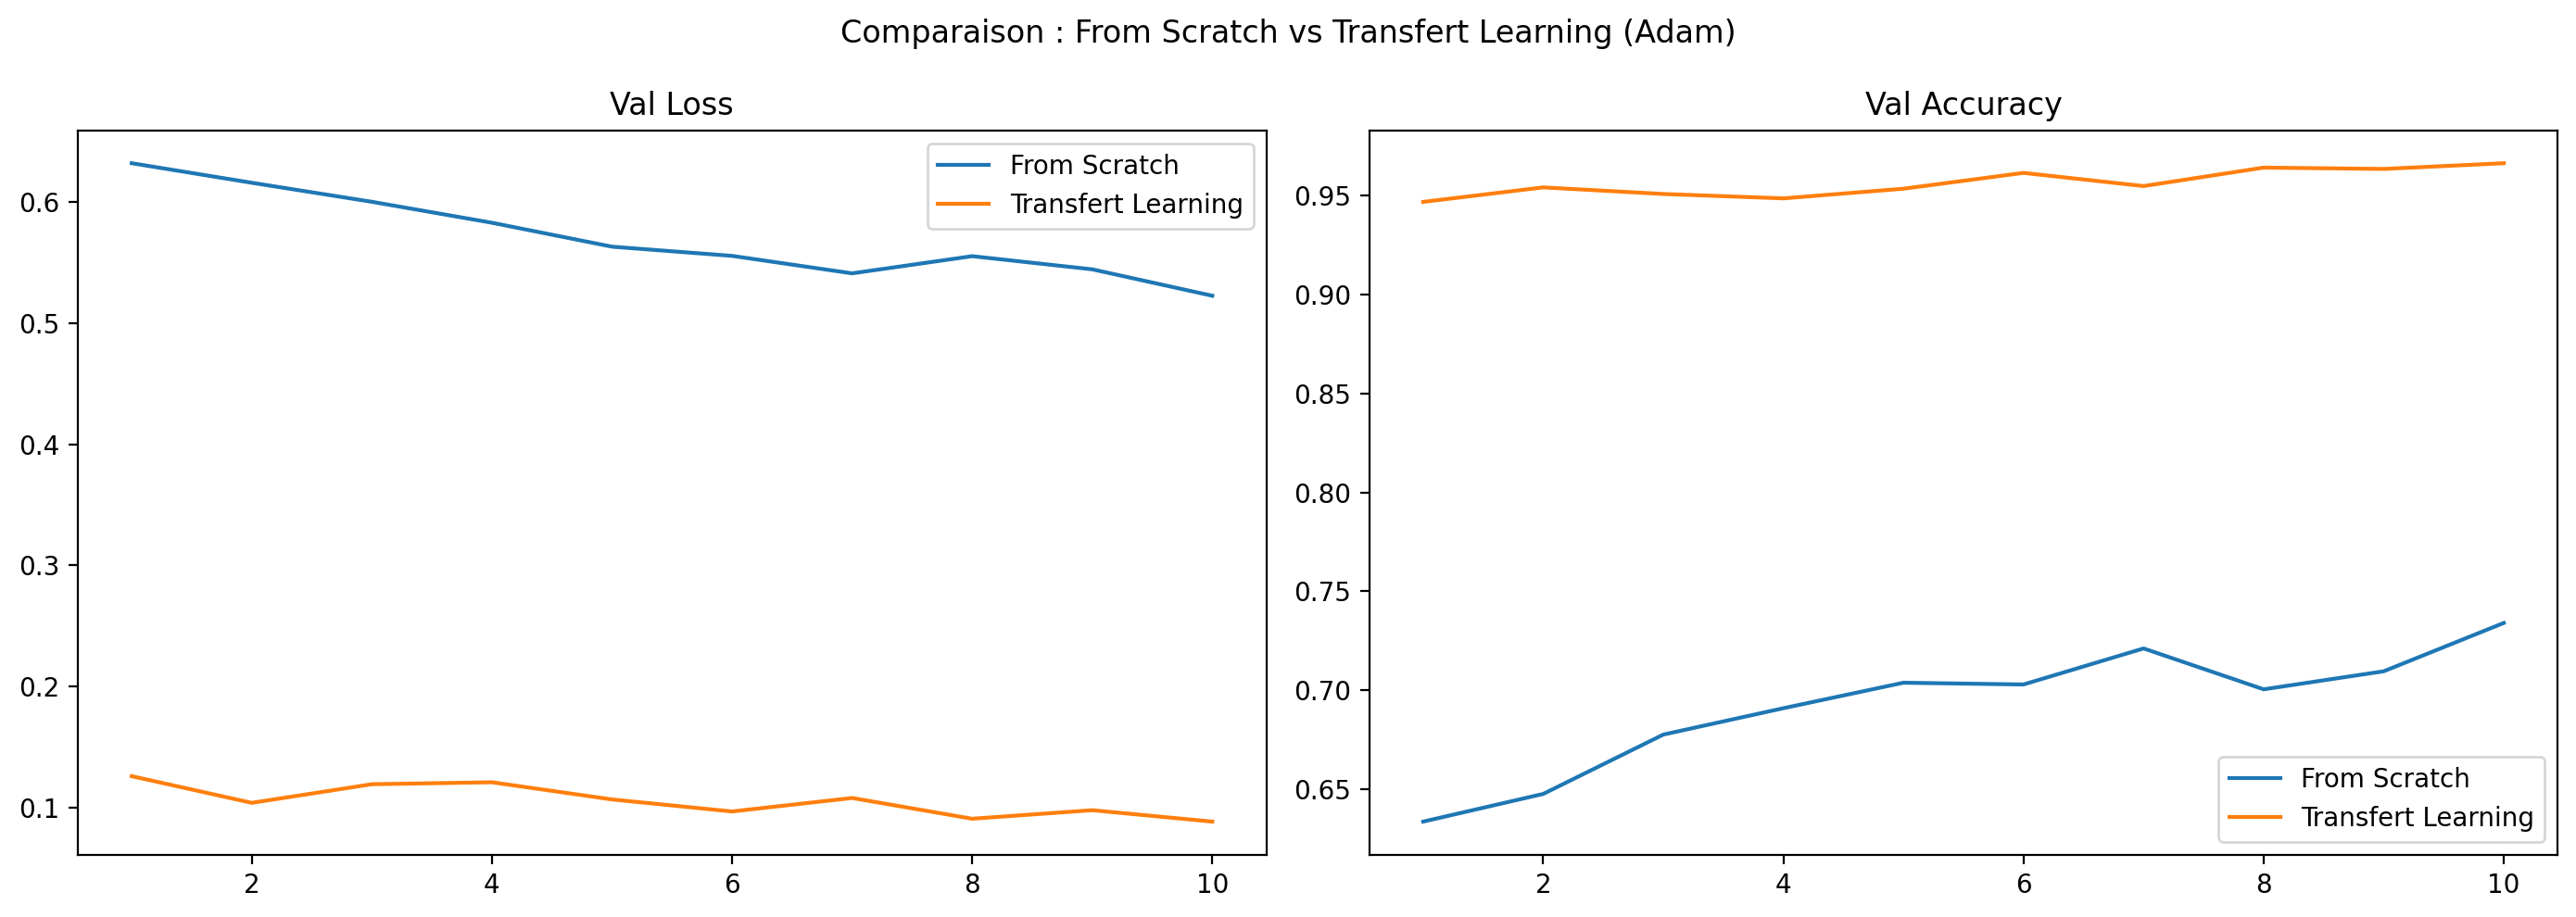

In [22]:
# Courbes de comparaison directe (val accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_s = range(1, len(history_scratch_adam['val_acc']) + 1)
epochs_t = range(1, len(history_tl_adam['val_acc']) + 1)

axes[0].plot(epochs_s, history_scratch_adam['val_loss'],   label='From Scratch')
axes[0].plot(epochs_t, history_tl_adam['val_loss'],        label='Transfert Learning')
axes[0].set_title('Val Loss'); axes[0].legend()

axes[1].plot(epochs_s, history_scratch_adam['val_acc'],    label='From Scratch')
axes[1].plot(epochs_t, history_tl_adam['val_acc'],         label='Transfert Learning')
axes[1].set_title('Val Accuracy'); axes[1].legend()

plt.suptitle('Comparaison : From Scratch vs Transfert Learning (Adam)')
plt.tight_layout()
plt.show()

## 6. Analyse des erreurs typiques

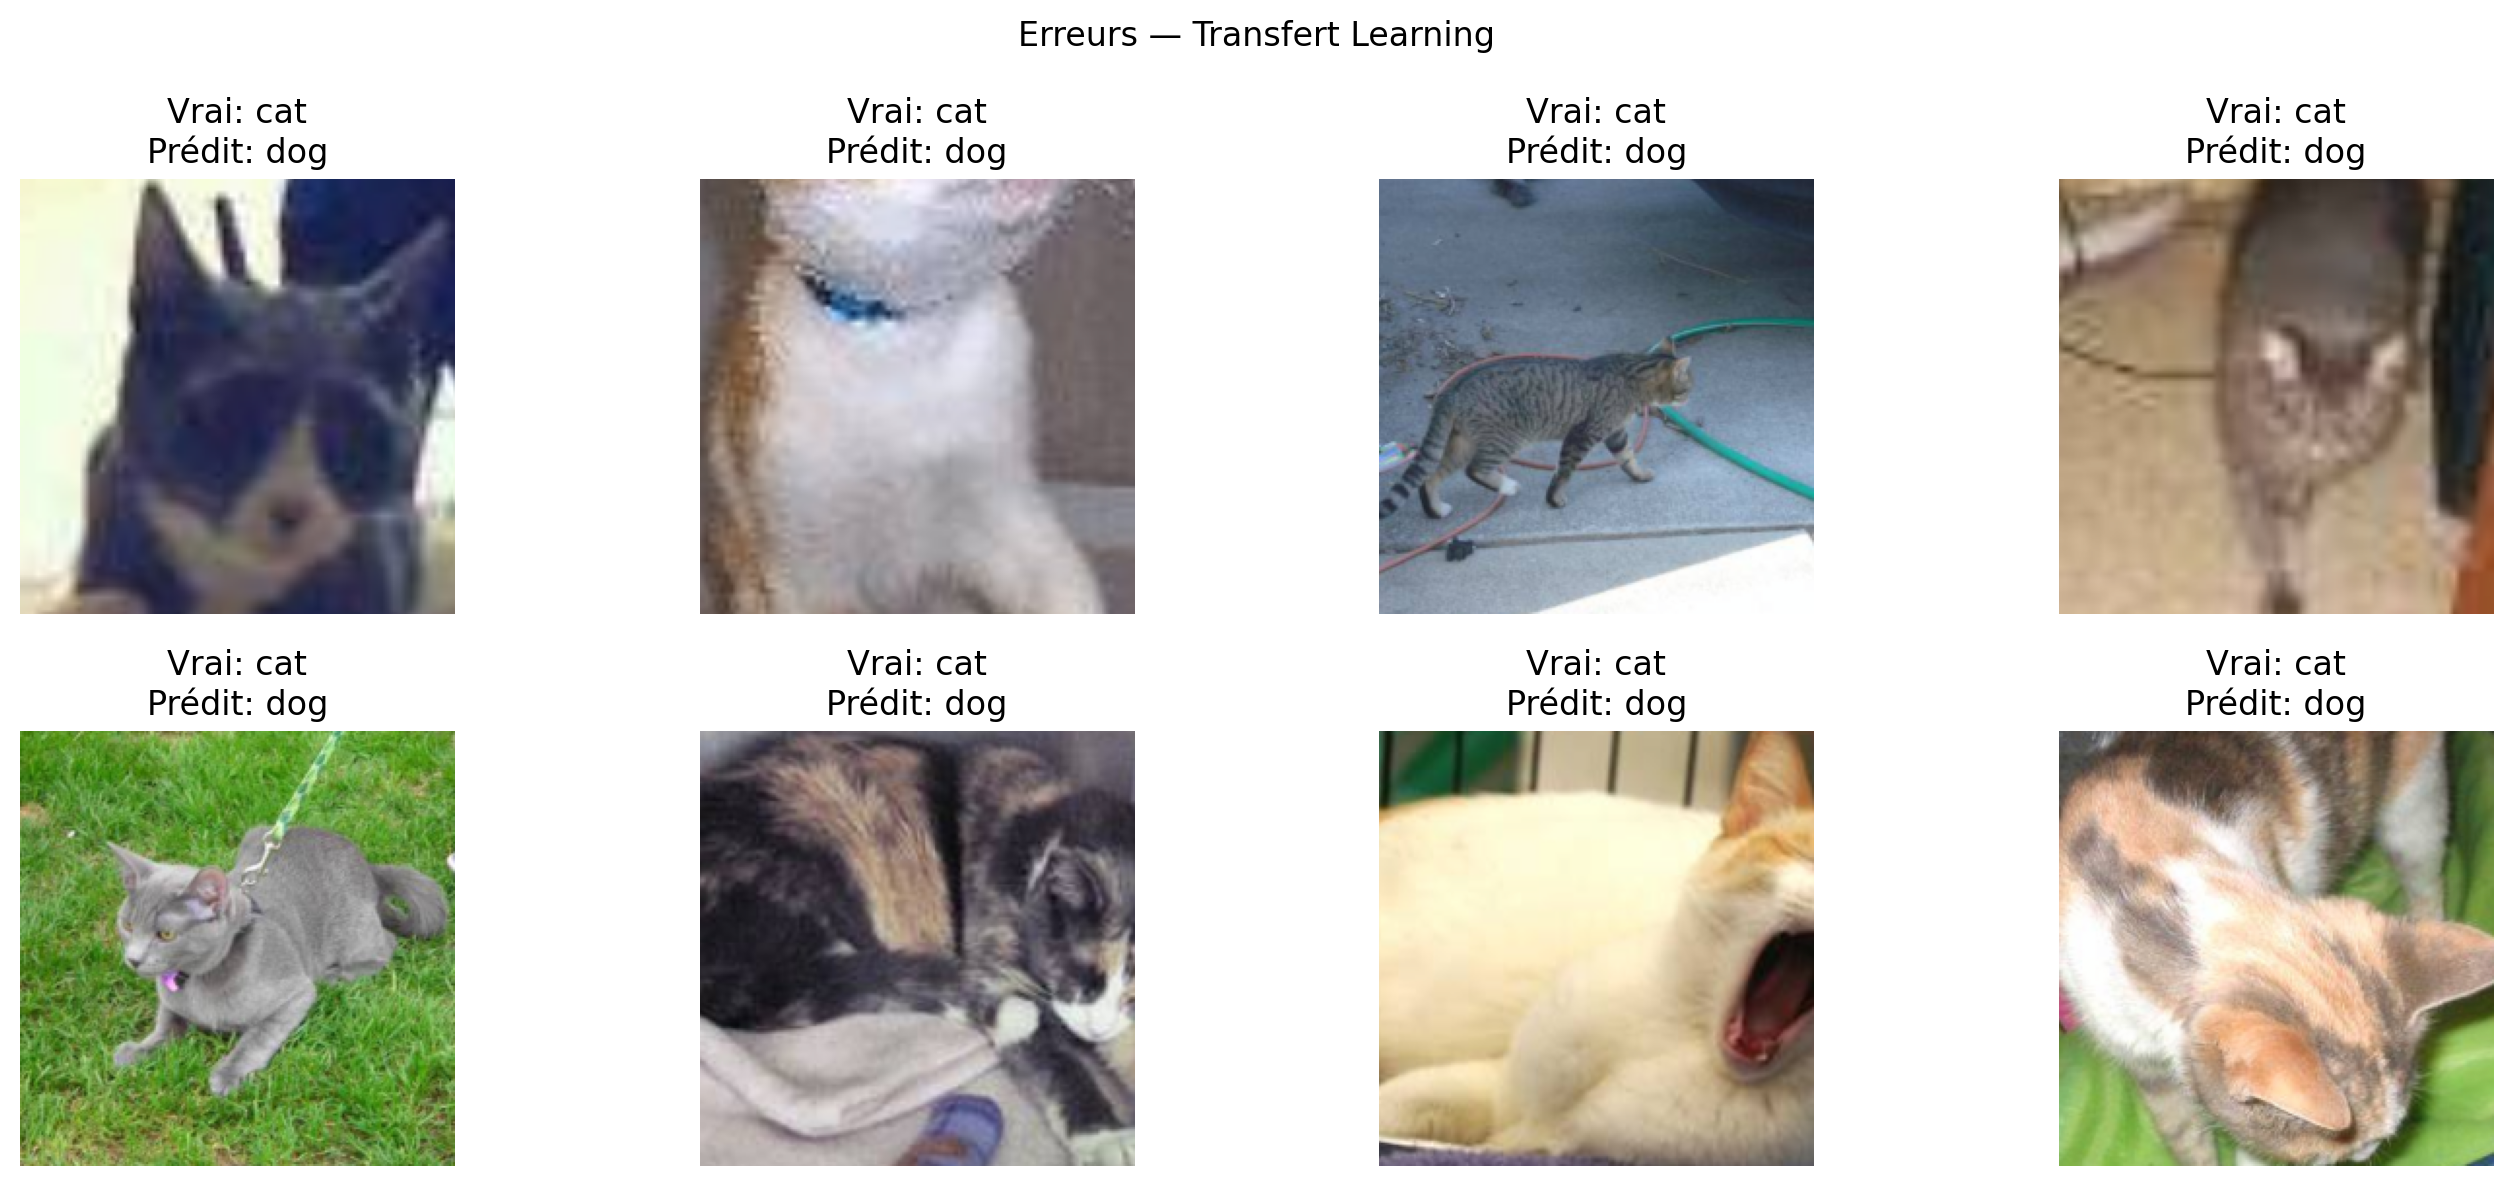

In [ ]:
@torch.no_grad()
def show_errors(model, loader, classes, n=8, title='Erreurs typiques'):
    
    model.eval()
    errors_imgs, errors_preds, errors_true = [], [], []
    for images, labels in loader:
        images_dev = images.to(device)
        outputs    = model(images_dev)
        _, preds   = torch.max(outputs, 1)
        mask = preds.cpu() != labels
        errors_imgs.extend(images[mask])
        errors_preds.extend(preds.cpu()[mask].tolist())
        errors_true.extend(labels[mask].tolist())
        if len(errors_imgs) >= n:
            break

    n = min(n, len(errors_imgs))
    fig, axes = plt.subplots(2, n // 2, figsize=(14, 6))
    for i, ax in enumerate(axes.flat):
        if i < n:
            imshow(errors_imgs[i], ax=ax)
            ax.set_title(f'Vrai: {classes[errors_true[i]]}\nPrédit: {classes[errors_preds[i]]}')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_errors(best_tl, testloader, train_data.classes, n=8, title='Erreurs — Transfert Learning')